In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import pandas as pd; pd.set_option("display.max_columns", None)
import sys;sys.path.append("..")

from config import Paths
from dataframes import *
import utils
from plot_utils import plot_trajectory_panels3

# import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
%autoreload

# Subjects

In [34]:
# Corrida nueva
# Load ZephyrX

### A. Permisive
at_least_efforts_fvc_usable=0
keep_usable_sessions_only=False
at_least_months_in_study=0
at_least_n_sessions=0
multiply_by_100=True

### B. Paper-like
at_least_efforts_fvc_usable=3
keep_usable_sessions_only=True
at_least_months_in_study=0
at_least_n_sessions=0
multiply_by_100=True


df_zephyrx_new = load_zephyrx_data(
    at_least_efforts_fvc_usable=at_least_efforts_fvc_usable,
    keep_usable_sessions_only=keep_usable_sessions_only,
    at_least_months_in_study=at_least_months_in_study,
    at_least_n_sessions=at_least_n_sessions,
    multiply_by_100=multiply_by_100,
)
print(f'N pALS: {df_zephyrx_new.user_id.nunique()}, N sessions: {df_zephyrx_new.session_id.nunique()}')

# Keep only one spirometry per session (best one)
df_best_fvc_per_session = df_zephyrx_new.query('pftType=="fvc"').sort_values(['user_id', 'fvcPercPred_2019'], ascending=False).groupby('session_id').first().reset_index()
df_best_svc_per_session = df_zephyrx_new.query('pftType=="svc"').sort_values(['user_id', 'vcPercPred'], ascending=False).groupby('session_id').first().reset_index()
df_zephyrx_new = pd.concat([df_best_fvc_per_session, df_best_svc_per_session])

# Conteo de pacientes, reemplazando el anterior de tirar slopes y demas para que sea mas claro que es lo que hace
all_patients = df_zephyrx_new.user_id.unique()
print(f'All patients: {len(all_patients)}')
all_patients_fvc = df_zephyrx_new.query('pftType=="fvc"').user_id.unique()
all_patients_svc = df_zephyrx_new.query('pftType=="svc"').user_id.unique()
print(f'Patients with FVC: {len(all_patients_fvc)}')
print(f'Patients with SVC: {len(all_patients_svc)}')
all_patients_fvc_svc = all_patients_fvc[np.isin(all_patients_fvc, all_patients_svc)]

print(f'N subjects: {df_zephyrx_new.user_id.nunique()}')
print(f'N sessions with both: {df_zephyrx_new.session_id.nunique()}')
n_fvc = df_zephyrx_new.query('pftType=="fvc"').session_id.nunique()
n_svc = df_zephyrx_new.query('pftType=="svc"').session_id.nunique()
print(f"N FVC sessions: {n_fvc}")
print(f"N SVC sessions: {n_svc}")

--- SCALING PERC PRED VARS TO PERCENTAGE: fvcPercPred_2019, vcPercPred
1 - ORIGINAL DIMENSIONS:                           subjects:     13, sessions:    123, spiro:    288, cols: 108
2 - CRITERIA: n_fvc_atleast_usable >= 3 or vc > 0  subjects:     12, sessions:    113, spiro:    187, cols: 109
--- WARNING computing 'total_timespan' for each user after usability criteria: True
--- TOTAL TIMESPAN: min 0, max 545, mean 336.83
--- NOT FILTERING SUBJECTS BY MINIMUM MONTHS IN STUDY
--- NOT FILTERING SUBJECTS BY MINIMUM NUMBER OF SESSIONS
N pALS: 12, N sessions: 113
All patients: 12
Patients with FVC: 8
Patients with SVC: 11
N subjects: 12
N sessions with both: 113
N FVC sessions: 61
N SVC sessions: 101


In [35]:
als_label = 'dyspnea'

df_als = load_alsfrsr_data()
df_zephyrx_new = df_zephyrx_new.merge(df_als[['session_id', als_label]].drop_duplicates(), how='left')

## Orden de sujetos para todo el trabajo

In [36]:
print('Keeping pALS with at least 3 pft in any modality')
print('n pALS before: ', df_zephyrx_new.user_id.nunique())
n_sessions_per_pft = df_zephyrx_new.groupby('user_id').pftType.value_counts().reset_index()
pals_for_regression = n_sessions_per_pft.groupby('user_id').apply(lambda sub: any(s>2 for s in sub['count']))
pals_for_regression = pals_for_regression[pals_for_regression].index
df_zephyrx_new = df_zephyrx_new.query('user_id in @pals_for_regression').copy()
print('n pALS after: ', df_zephyrx_new.user_id.nunique())

Keeping pALS with at least 3 pft in any modality
n pALS before:  12
n pALS after:  10


In [ ]:
all_patients_sorted = df_zephyrx_new.query('pftType=="fvc"').groupby('user_id').size().sort_values(ascending=False).index.tolist()
all_patients_sorted.extend([u for u in df_zephyrx_new.user_id.unique() if u not in all_patients_sorted])
print("Total patients: ", len(all_patients_sorted))

Total patients:  10


In [ ]:
RECOMPUTE = False

if RECOMPUTE:
    # Enumerar el orden de los pacientes como pALS 1, ... en orden descendente de intercept_fvcPercPred_2019 y guardarlo en un csv
    order = {patient: f'pALS {i+1}' for i, patient in enumerate(all_patients_sorted)}
    df_order = pd.DataFrame.from_dict(order, orient='index', columns=['subject_order'])
    df_order.index.name = 'user_id'
    df_order.reset_index(inplace=True)
    df_order.to_csv('../data/df_order.csv', index=False)
else:
    df_order = pd.read_csv('../data/df_order.csv')

# Figura

In [47]:
colors = sns.color_palette("colorblind").as_hex()

data_dict_fvc_svc = [

    # {'var_name': 'fvcPercPred_2019',
    # 'hue_query_fit': [
    #         'is_proctored', None
    # ],
    # 'hue_names_fit':  [None, None],
    # 'hue_query_plot': [ 
    #     'is_proctored', 'not is_proctored'
    # ],
    # 'hue_names_plot': ['FVC proc', 'FVC non-proc'],
    # 'alpha': [1, 1],
    # 'marker':['o'],
    # 'size':[50, 50],
    # 'alpha_lr': 1,
    # 'color_1': 'blue',
    # 'color_2': colors[0],
    # 'color_3': colors[0],
    # 'color_4': 'blue',
    # 'label_y': 'FVC % predicted',
    # 'ylim': (-5, 150),
    # 'yticks': [0, 50, 100, 150],
    # 'yticklabels': [0, 50, 100, 150],
    # },

    {'var_name': 'vcPercPred',
    'hue_query_fit': ['is_proctored', None],
    'hue_names_fit':  [None, None],
    'hue_query_plot': ['is_proctored', 'not is_proctored'],
    'hue_names_plot': ['SVC proc', 'SVC non-proc'],
    'alpha': [1, 1],
    'marker':['o'],
    'size':[50, 50],
    'alpha_lr':1,
    'color_1': 'blue',
    'color_2': colors[3],
    'color_3': colors[3],
    'color_4': 'orange',
    'label_y': 'SVC % predicted',
    'ylim': (-5, 150),
    'yticks': [0, 50, 100, 150],
    'yticklabels': [0, 50, 100, 150],
    },

    {'var_name': als_label,
    'hue_query_fit': ['is_proctored', None],
    'hue_names_fit':  [None, None],
    'hue_query_plot': ['is_proctored', 'not is_proctored'],
    'hue_names_plot': ['Q10 proc', 'Q10 non-proc'],
    'alpha': [1, 1],
    'marker':['o'],
    'size':[50, 50],
    'alpha_lr':1,
    'color_1': 'green',
    'color_2': 'green',
    'color_3': 'green',
    'color_4': 'green',
    'label_y': 'Q10',
    'ylim': (-1, 5),
    'yticks': [0, 1, 2, 3, 4],
    'yticklabels': [0, 1, 2, 3, 4],
    },

]

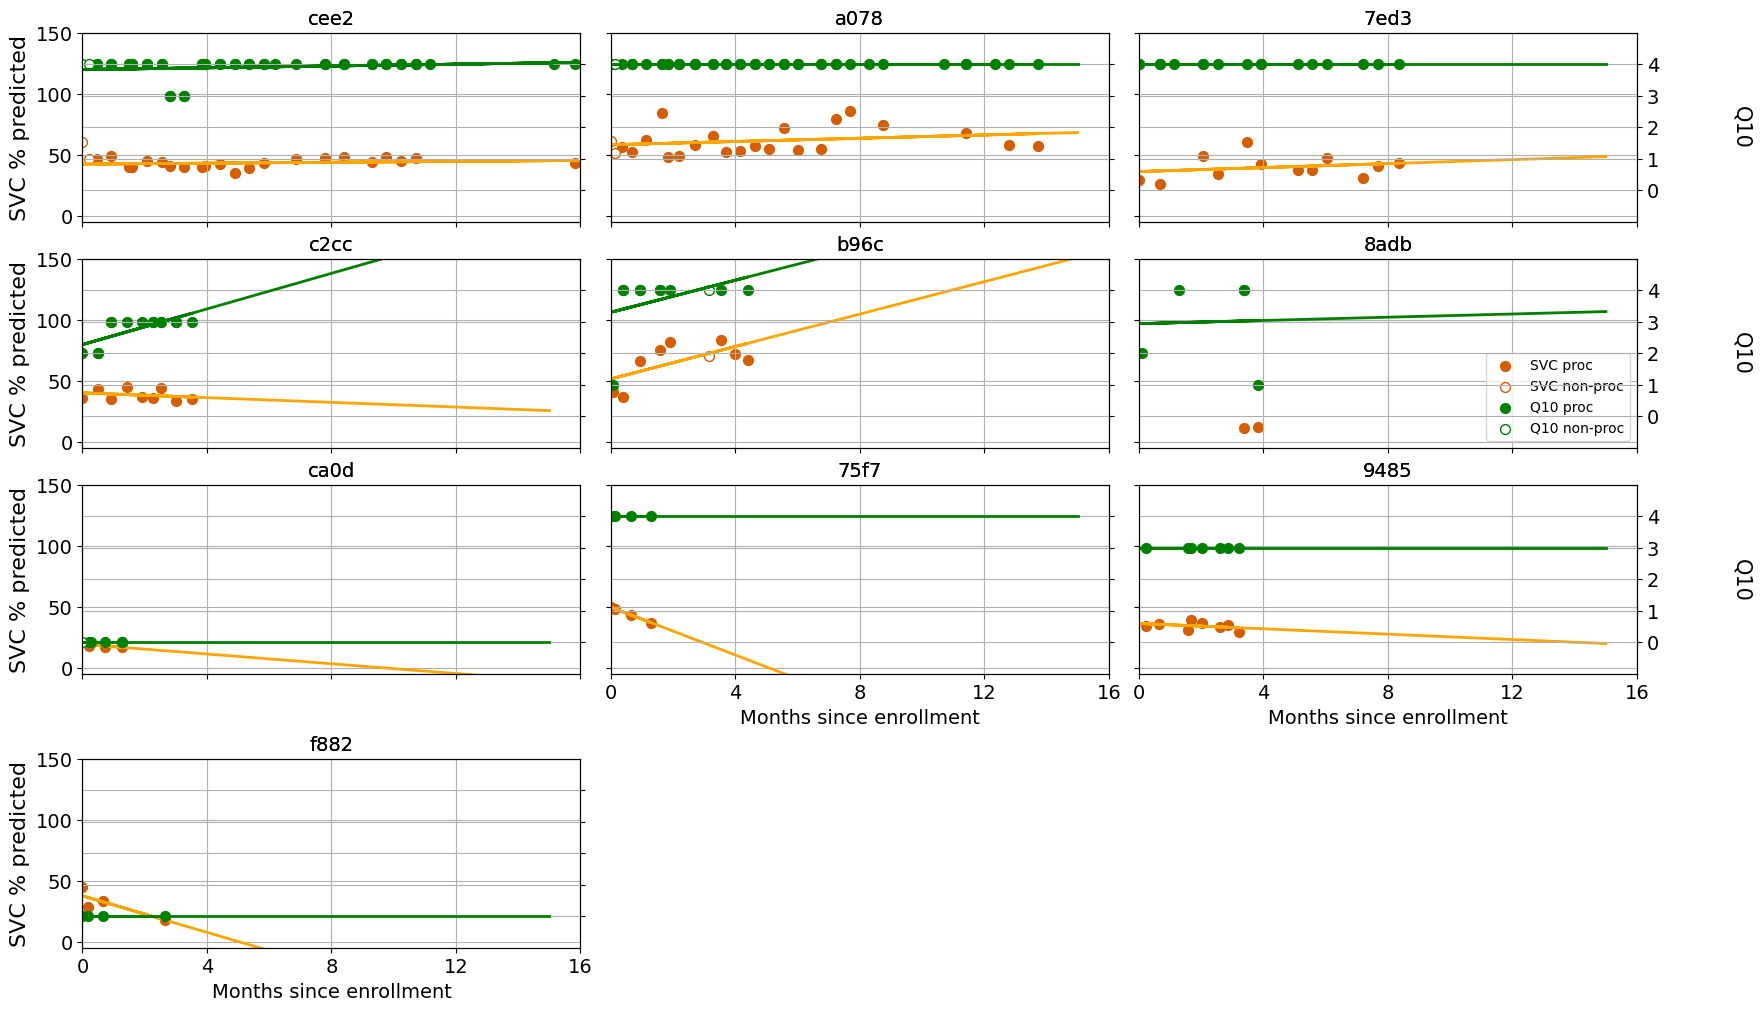

In [48]:
time_col = "months_since_first_session"
xlim = (0, 16)

for n_pat in [(0, 10)]:
    titles = [pat['user_id'][:4] for _, pat in df_order.iloc[n_pat[0]:n_pat[1]].iterrows()]
    fig = plot_trajectory_panels3(
        df_zephyrx_new,
        df_order.user_id[n_pat[0]:n_pat[1]],
        n_rows = 4,
        n_cols = 3,
        time_col=time_col,
        limit=None,
        data_dict=data_dict_fvc_svc,
        xlim=xlim,
        do_legend=True,
        do_legend_index=5,
        legend_loc="lower right",
        mute_titles=False,
        mute_x_ticks=True,
        plot_regression_line=True,
        extend_regression=True,
        fill_between=False,
        titles=titles,
        fs=14,
        xlabel='Months since enrollment',
    )